# 05 · Conditional Mean Shift Analysis

Computes the implied conditional displacement of SEVERITY under three conditioning
sets across all six main-specification network contexts. Implements the closed-form
Gaussian conditional mean formula described in Chapter 6 of the thesis.

**Inputs:** Estimated network `.rds` objects from `02_ggm_estimation` (main spec, g05).

**Outputs:**
- `cms_results.csv` — full displacement table
- `fig_cms_heatmap.png` — primary heatmap (thesis Figure VI.1)
- `fig_cms_full_vectors.png` — full displacement vectors (thesis Figure VI.2)


In [1]:
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

try:
    import pyreadr
except ImportError:
    import subprocess, sys
    subprocess.check_call([sys.executable, "-m", "pip", "install", "pyreadr", "-q"])
    import pyreadr

# ── Paths ─────────────────────────────────────────────────────────────────────
BASE_DIR    = Path("..")
NETWORK_DIR = BASE_DIR / "results" / "networks"
IMAGE_DIR   = BASE_DIR / "images"
IMAGE_DIR.mkdir(parents=True, exist_ok=True)

print("NETWORK_DIR:", NETWORK_DIR.resolve())
print("IMAGE_DIR  :", IMAGE_DIR.resolve())


NETWORK_DIR: C:\Users\Ciinz\Desktop\ThesisFinal\Results\networks
IMAGE_DIR  : C:\Users\Ciinz\Desktop\ThesisFinal\Images


In [2]:
# ── Node ordering and conditioning sets ────────────────────────────────────────
# Must match the estimation notebook exactly.
NODE_VARS = [
    "SEVERITY",
    "AFF_FEAR", "AFF_WORRY", "WORRY_HEALTH_SYSTEM",
    "USE2_MASK", "USE2_SPACE150", "USE2_HANDWASH20", "USE2_AVOID",
]

FOCAL_IDX = 0  # SEVERITY

# Conditioning sets (by index into NODE_VARS)
COND_SETS = {
    "AFF_FEAR only":   [1],
    "Affect domain":   [1, 2, 3],
    "Behavior domain": [4, 5, 6, 7],
}

# Contexts
CONTEXTS = [
    {"wave": 55, "trust": "low",  "n": 376},
    {"wave": 55, "trust": "high", "n": 309},
    {"wave": 56, "trust": "low",  "n": 383},
    {"wave": 56, "trust": "high", "n": 351},
    {"wave": 57, "trust": "low",  "n": 336},
    {"wave": 57, "trust": "high", "n": 407},
]

NODE_DOMAIN = {
    "SEVERITY": "belief",
    "AFF_FEAR": "affect", "AFF_WORRY": "affect", "WORRY_HEALTH_SYSTEM": "affect",
    "USE2_MASK": "behavior", "USE2_SPACE150": "behavior",
    "USE2_HANDWASH20": "behavior", "USE2_AVOID": "behavior",
}

print("Conditioning sets:", list(COND_SETS.keys()))
print("Contexts:", len(CONTEXTS))


Conditioning sets: ['AFF_FEAR only', 'Affect domain', 'Behavior domain']
Contexts: 6


In [3]:
# ── Conditional mean shift function ────────────────────────────────────────────
# Implements Eq. 6.1–6.2 from the thesis.
# For standardized variables: mu=0, Sigma=R (correlation matrix).
# Delta_i = Sigma_YX @ inv(Sigma_XX) @ x_shift

def conditional_mean_shift(Sigma, x_idx, y_idx, c=1.0):
    """
    Sigma  : full correlation matrix (p x p numpy array)
    x_idx  : list of column indices for conditioning set X
    y_idx  : list of column indices for outcome set Y
    c      : shift magnitude in SD units (default +1)
    Returns: Delta_Y, implied displacement of Y nodes in SD units
    """
    Sigma_YX = Sigma[np.ix_(y_idx, x_idx)]
    Sigma_XX = Sigma[np.ix_(x_idx, x_idx)]
    x_shift  = np.full(len(x_idx), c)  # uniform shift in SD units
    delta    = Sigma_YX @ np.linalg.solve(Sigma_XX, x_shift)
    return delta

print("conditional_mean_shift() defined.")


conditional_mean_shift() defined.


In [4]:
# ── Load data and compute CMS ────────────────────────────────────────────────

results = []

for ctx in CONTEXTS:
    wave, trust, n_cc = ctx["wave"], ctx["trust"], ctx["n"]
    
    # Load instance data directly — no .rds needed
    instance_name = f"cosmo_nodes_wave{wave}_trust{trust}.csv"
    data_path = Path("..") / "data" / "instances" / instance_name
    
    if not data_path.exists():
        print(f"MISSING: {data_path}")
        continue
    
    dat = pd.read_csv(data_path)
    dat = dat[NODE_VARS].apply(pd.to_numeric)
    
    # Pearson correlation matrix = Sigma (since variables are standardized in GGM)
    R = dat.corr(method="pearson").values
    
    # Compute CMS for each conditioning set
    for cond_name, x_idx in COND_SETS.items():
        y_idx_all = [i for i in range(len(NODE_VARS)) if i not in x_idx]
        
        delta_all = conditional_mean_shift(R, x_idx, y_idx_all, c=1.0)
        
        focal_pos_in_y = y_idx_all.index(FOCAL_IDX)
        delta_severity = delta_all[focal_pos_in_y]
        
        row = {
            "wave": wave,
            "trust_stratum": trust,
            "n_cc": n_cc,
            "conditioning_set": cond_name,
            "delta_SEVERITY": round(delta_severity, 3),
        }
        
        for i, yi in enumerate(y_idx_all):
            row[f"delta_{NODE_VARS[yi]}"] = round(delta_all[i], 3)
        
        results.append(row)
    
    print(f"  wave={wave} trust={trust}: done")

cms_df = pd.DataFrame(results)
cms_df.to_csv(NETWORK_DIR / "cms_results.csv", index=False)
print(f"\nSaved: cms_results.csv ({len(cms_df)} rows)")
print()

pivot = cms_df.pivot_table(
    index="conditioning_set",
    columns=["wave", "trust_stratum"],
    values="delta_SEVERITY",
)
print("Delta_SEVERITY (SD units, c=+1):")
print(pivot.to_string())

  wave=55 trust=low: done
  wave=55 trust=high: done
  wave=56 trust=low: done
  wave=56 trust=high: done
  wave=57 trust=low: done
  wave=57 trust=high: done

Saved: cms_results.csv (18 rows)

Delta_SEVERITY (SD units, c=+1):
wave                 55            56            57       
trust_stratum      high    low   high    low   high    low
conditioning_set                                          
AFF_FEAR only     0.418  0.511  0.330  0.545  0.377  0.399
Affect domain     0.530  0.663  0.390  0.687  0.417  0.587
Behavior domain   0.383  0.377  0.391  0.407  0.175  0.381


## Figure 1: CMS heatmap

Primary result figure — $\Delta_{\text{SEVERITY}}$ across conditioning sets and contexts.
Corresponds to thesis Figure VI.1 (`fig_cms_heatmap.png`).


Saved: fig_cms_heatmap.png


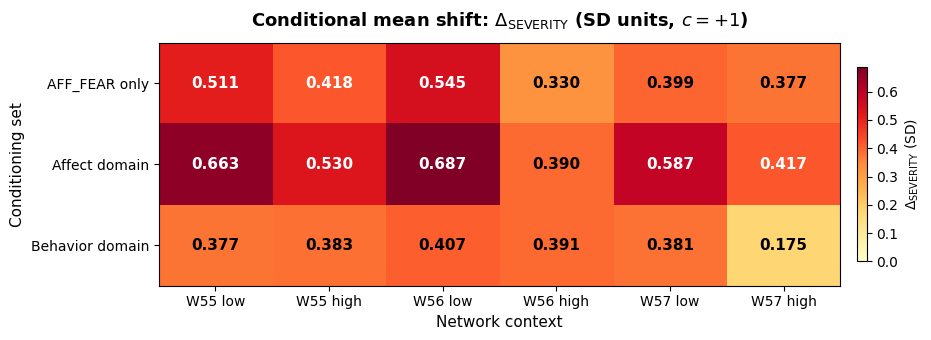

In [5]:
# ── Figure: CMS heatmap ───────────────────────────────────────────────────────

# Reshape for heatmap
heatmap_data = cms_df[["wave", "trust_stratum", "conditioning_set", "delta_SEVERITY"]].copy()
heatmap_data["context"] = heatmap_data.apply(
    lambda r: f"W{r['wave']} {r['trust_stratum']}", axis=1
)

# Order: conditioning sets as rows, contexts as columns
cond_order = ["AFF_FEAR only", "Affect domain", "Behavior domain"]
ctx_order = [f"W{w} {t}" for w in [55, 56, 57] for t in ["low", "high"]]

pivot_heat = heatmap_data.pivot(
    index="conditioning_set", columns="context", values="delta_SEVERITY"
)
pivot_heat = pivot_heat.reindex(index=cond_order, columns=ctx_order)

fig, ax = plt.subplots(figsize=(10, 3.5))

# Color map: zero-anchored warm
vmax = pivot_heat.max().max()
im = ax.imshow(
    pivot_heat.values, cmap="YlOrRd", aspect="auto",
    vmin=0, vmax=max(vmax, 0.6)
)

# Labels
ax.set_xticks(range(len(ctx_order)))
ax.set_xticklabels(ctx_order, fontsize=10)
ax.set_yticks(range(len(cond_order)))
ax.set_yticklabels(cond_order, fontsize=10)

# Annotate cells
for i in range(len(cond_order)):
    for j in range(len(ctx_order)):
        val = pivot_heat.values[i, j]
        color = "white" if val > vmax * 0.6 else "black"
        ax.text(j, i, f"{val:.3f}", ha="center", va="center",
                fontsize=11, fontweight="bold", color=color)

ax.set_xlabel("Network context", fontsize=11)
ax.set_ylabel("Conditioning set", fontsize=11)
ax.set_title(
    r"Conditional mean shift: $\Delta_{\mathrm{SEVERITY}}$ (SD units, $c = +1$)",
    fontsize=13, fontweight="bold", pad=12
)

cbar = fig.colorbar(im, ax=ax, shrink=0.8, pad=0.02)
cbar.set_label(r"$\Delta_{\mathrm{SEVERITY}}$ (SD)", fontsize=10)

plt.tight_layout()
fig.savefig(IMAGE_DIR / "fig_cms_heatmap.png", dpi=300, bbox_inches="tight")
print("Saved: fig_cms_heatmap.png")
plt.show()


## Figure 2: Full displacement vectors

Secondary analysis — full $\Delta$ vector across all 8 nodes under affect-domain
conditioning, comparing wave 55 low-trust vs. wave 55 high-trust.
Corresponds to thesis Figure VI.2 (`fig_cms_full_vectors.png`).


Saved: fig_cms_full_vectors.png


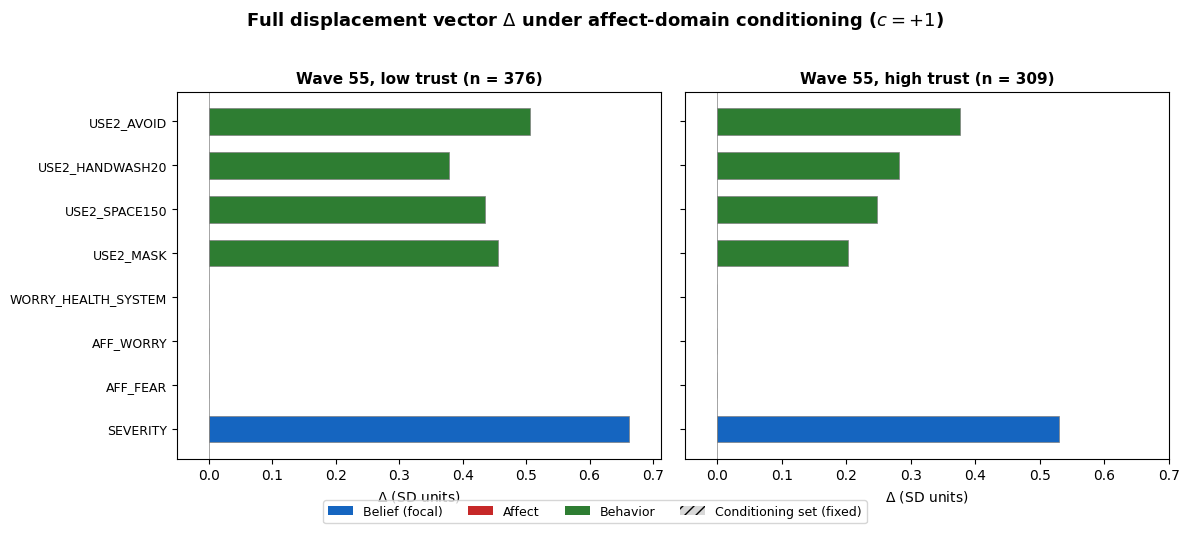

In [6]:
# ── Figure: Full displacement vectors ─────────────────────────────────────────

# Extract affect-domain results for wave 55, both trust strata
affect_rows = cms_df[
    (cms_df["conditioning_set"] == "Affect domain") &
    (cms_df["wave"] == 55)
].copy()

# Build displacement vectors
delta_cols = [c for c in cms_df.columns if c.startswith("delta_")]
node_names_from_cols = [c.replace("delta_", "") for c in delta_cols]

# For affect-domain conditioning, the affect nodes (AFF_FEAR, AFF_WORRY,
# WORRY_HEALTH_SYSTEM) are the conditioning set — their displacement is
# not computed (they're fixed at +1 SD). We set them to 0 for display
# and mark them separately.

all_nodes = NODE_VARS.copy()
affect_indices = [1, 2, 3]  # indices of conditioning set nodes

fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

domain_colors = {
    "belief": "#1565C0",
    "affect": "#C62828",
    "behavior": "#2E7D32",
}

for ax_idx, trust in enumerate(["low", "high"]):
    ax = axes[ax_idx]
    row = affect_rows[affect_rows["trust_stratum"] == trust].iloc[0]
    n_cc = int(row["n_cc"])
    
    # Build full delta vector
    deltas = []
    for i, node in enumerate(all_nodes):
        col = f"delta_{node}"
        if i in affect_indices:
            # Conditioning set: fixed, not displaced
            deltas.append(0.0)
        elif col in row.index:
            deltas.append(row[col])
        else:
            deltas.append(0.0)
    
    colors = [domain_colors[NODE_DOMAIN[n]] for n in all_nodes]
    
    # Hatch pattern for conditioning set nodes
    bars = ax.barh(range(len(all_nodes)), deltas, color=colors, edgecolor="gray",
                   linewidth=0.5, height=0.6)
    
    # Mark conditioning set with different pattern
    for i in affect_indices:
        bars[i].set_hatch("///")
        bars[i].set_alpha(0.3)
    
    ax.set_yticks(range(len(all_nodes)))
    ax.set_yticklabels(all_nodes, fontsize=9)
    ax.set_xlabel(r"$\Delta$ (SD units)", fontsize=10)
    ax.set_title(f"Wave 55, {trust} trust (n = {n_cc})", fontsize=11, fontweight="bold")
    ax.axvline(0, color="gray", linewidth=0.5)
    ax.set_xlim(-0.05, max(0.7, max(deltas) + 0.05))
    ax.invert_yaxis()

# Add legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor=domain_colors["belief"], label="Belief (focal)"),
    Patch(facecolor=domain_colors["affect"], label="Affect"),
    Patch(facecolor=domain_colors["behavior"], label="Behavior"),
    Patch(facecolor="gray", alpha=0.3, hatch="///", label="Conditioning set (fixed)"),
]
fig.legend(handles=legend_elements, loc="lower center", ncol=4, fontsize=9,
           bbox_to_anchor=(0.5, -0.02))

fig.suptitle(
    r"Full displacement vector $\Delta$ under affect-domain conditioning ($c = +1$)",
    fontsize=13, fontweight="bold", y=1.02
)

plt.tight_layout()
fig.savefig(IMAGE_DIR / "fig_cms_full_vectors.png", dpi=300, bbox_inches="tight")
print("Saved: fig_cms_full_vectors.png")
plt.show()


In [7]:
# ── Verification ────────────────
print("CMS results summary:")
print("=" * 65)

pivot = cms_df.pivot_table(
    index="conditioning_set",
    columns=["wave", "trust_stratum"],
    values="delta_SEVERITY",
)
print(pivot.to_string())
print()
print(f"Total rows: {len(cms_df)}")
print(f"Contexts:   {cms_df[['wave','trust_stratum']].drop_duplicates().shape[0]}")
print(f"Cond sets:  {cms_df['conditioning_set'].nunique()}")

CMS results summary:
wave                 55            56            57       
trust_stratum      high    low   high    low   high    low
conditioning_set                                          
AFF_FEAR only     0.418  0.511  0.330  0.545  0.377  0.399
Affect domain     0.530  0.663  0.390  0.687  0.417  0.587
Behavior domain   0.383  0.377  0.391  0.407  0.175  0.381

Total rows: 18
Contexts:   6
Cond sets:  3
